<a href="https://colab.research.google.com/github/sahoop2002/maths-for-DS/blob/main/Session_40%2C41_PRATIP_Probability%20Distribution%20Functions%20-%20PDF%2C%20PMF%20%26%20CDF%20and%20Normal_Distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import random

In [ ]:
L = []
for i in range(10000):
    L.append(random.randint(1,6))

In [ ]:
len(L)

10000

In [ ]:
L[:5]

[4, 2, 5, 6, 5]

In [ ]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

<Axes: >

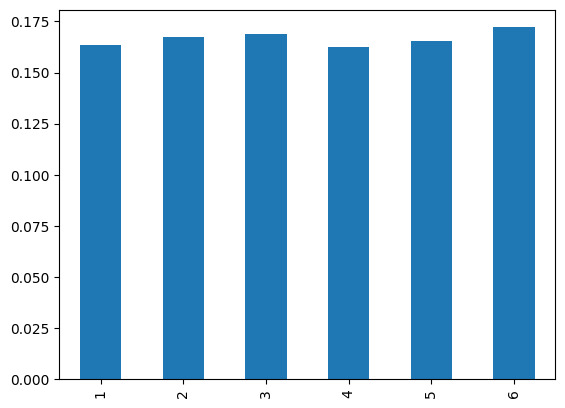

In [ ]:
s.plot(kind = 'bar')

In [ ]:
# for 2 dice
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)

  L.append(a + b)

In [ ]:
len(L)

10000

In [ ]:
L[:5]

[5, 10, 12, 3, 10]

In [ ]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [ ]:
import numpy as np
np.cumsum(s)

,count
2,0.0249
3,0.0870
4,0.1682
5,0.2769
6,0.4157
7,0.5863
8,0.7225
9,0.8343
10,0.9153
11,0.9702


<Axes: >

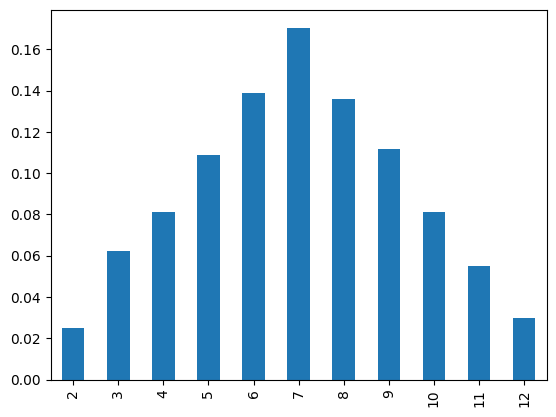

In [ ]:
s.plot(kind='bar')

<Axes: >

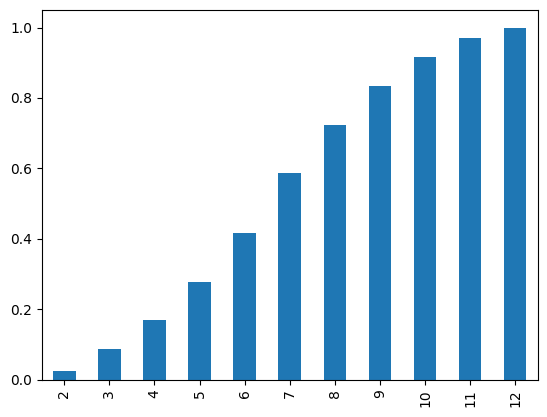

In [ ]:
np.cumsum(s).plot(kind='bar')

# Parametric Density Estimation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000)

In [ ]:
sample.mean()

np.float64(50.00527295432167)

(array([  1.,  12.,  40., 135., 249., 240., 200.,  85.,  31.,   7.]),
 array([32.12676081, 35.49498066, 38.8632005 , 42.23142035, 45.5996402 ,
        48.96786004, 52.33607989, 55.70429974, 59.07251958, 62.44073943,
        65.80895928]),
 <BarContainer object of 10 artists>)

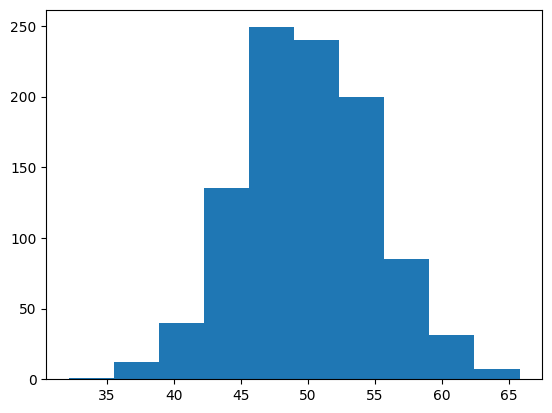

In [ ]:
# plot histogram to understand the distribution of data
plt.hist(sample,bins=10)

In [ ]:
# calculate sample mean and sample std dev
sample_mean = sample.mean()
sample_std = sample.std()

In [ ]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [ ]:
values = np.linspace(sample.min(),sample.max(),100)

In [ ]:
sample.max()

np.float64(65.80895927882418)

In [ ]:
probabilities = [dist.pdf(value) for value in values]

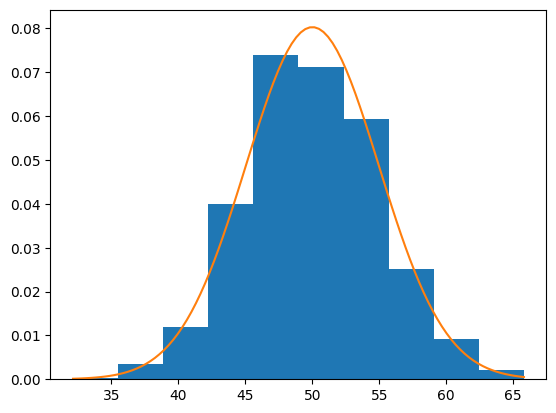

In [ ]:
# plot the histogram and pdf
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

/tmp/ipykernel_900/1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

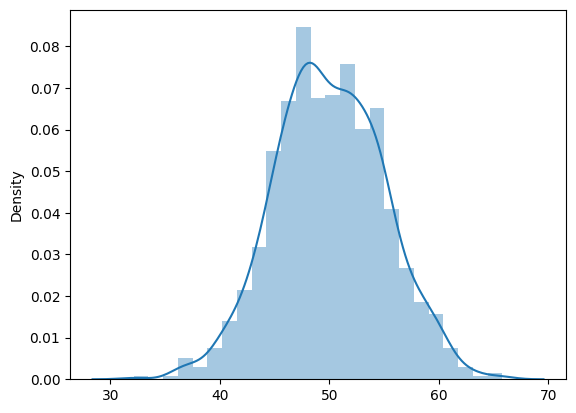

In [ ]:
import seaborn as sns
sns.distplot(sample)

In [ ]:
# if we change mean and standard deviation with some other value

from scipy.stats import norm
dist = norm(60, 12)
values = np.linspace(sample.min(),sample.max(),100)

In [ ]:
sample.max()

np.float64(65.80895927882418)

In [ ]:
probabilities = [dist.pdf(value) for value in values]

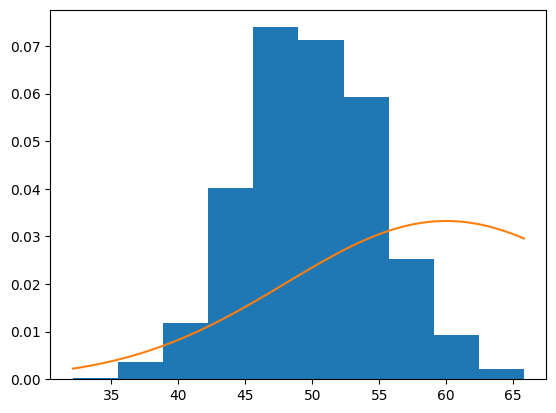

In [ ]:
# if data won't be right pdf won't plot correctly
plt.hist(sample,bins=10,density=True)
plt.plot(values,probabilities)

# KDE`[Kernel Density Estimation]`

In [ ]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [ ]:
sample

array([22.1704686 , 26.44254265, 22.02967165, 24.33534216, 16.71633101,
       16.76845606, 20.54911889, 25.19245576, 16.37935815, 18.34811462,
       23.26820943, 21.63512039, 18.46662627, 23.46051231, 21.69425492,
       16.17097959, 17.75447246, 16.62198214, 11.1237709 , 14.37252225,
       19.93952792, 26.70950292, 13.3525584 , 15.40677677, 19.69550857,
       20.52937573, 20.56896745, 31.64074504, 25.35036057, 16.68946958,
       23.04234402, 24.83854642, 22.75604761, 23.9261023 , 21.42838873,
       18.85493974, 10.62433318, 12.90471473, 25.60326187, 15.64755396,
       22.84545606,  7.38439124, 17.63839049, 29.43502487, 12.3369082 ,
       24.2256387 , 18.86582999, 20.6935119 , 21.35899777, 15.32689606,
       14.91401504, 24.73006784, 20.74889877, 20.88914552, 22.85262414,
       18.74620445, 16.64501471, 16.12610729, 25.94478545, 14.52874891,
       19.85749428, 20.90883733, 10.82264797, 18.32771485, 16.53445622,
       25.22345517, 21.54051224, 20.20218465, 22.95880454, 21.15

(array([ 1.,  0.,  3.,  6.,  3.,  7.,  8., 11., 14., 16., 15., 24., 14.,
        20., 29., 31., 23., 15., 13., 17., 13., 12.,  5.,  8., 10., 18.,
        16., 21., 33., 30., 35., 29., 55., 50., 48., 44., 41., 58., 47.,
        40., 27., 24., 23., 17., 13.,  5.,  5.,  1.,  1.,  1.]),
 array([ 7.38439124,  8.32218708,  9.25998291, 10.19777875, 11.13557459,
        12.07337043, 13.01116627, 13.94896211, 14.88675794, 15.82455378,
        16.76234962, 17.70014546, 18.6379413 , 19.57573714, 20.51353297,
        21.45132881, 22.38912465, 23.32692049, 24.26471633, 25.20251216,
        26.140308  , 27.07810384, 28.01589968, 28.95369552, 29.89149136,
        30.82928719, 31.76708303, 32.70487887, 33.64267471, 34.58047055,
        35.51826639, 36.45606222, 37.39385806, 38.3316539 , 39.26944974,
        40.20724558, 41.14504142, 42.08283725, 43.02063309, 43.95842893,
        44.89622477, 45.83402061, 46.77181644, 47.70961228, 48.64740812,
        49.58520396, 50.5229998 , 51.46079564, 52.39859147,

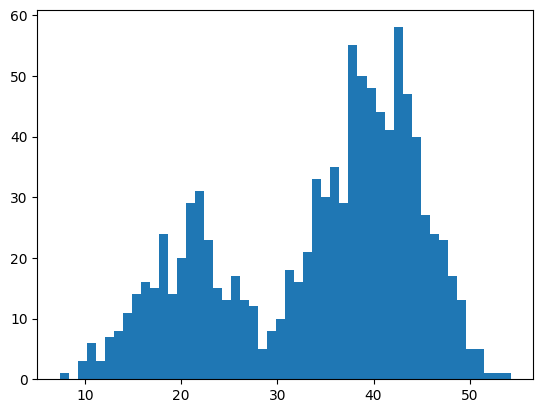

In [ ]:
# plot histogram bins=50
plt.hist(sample,bins=50)

In [ ]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=3, kernel='gaussian') # if we increase the bandwidth the graph will be smooth and for decrease it will be peaked

# convert data to a 2D array
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=3)

In [ ]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [ ]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

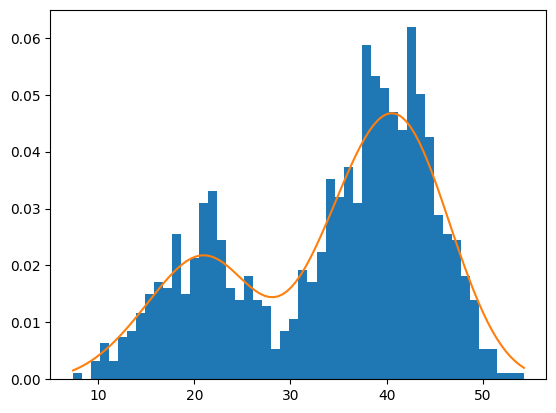

In [ ]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()

<Axes: ylabel='Density'>

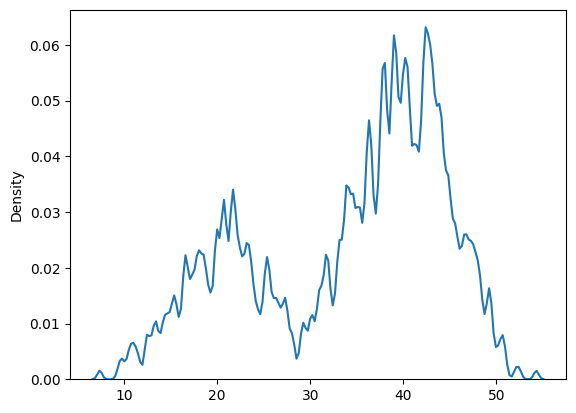

In [ ]:
sns.kdeplot(sample.reshape(1000),bw_adjust=0.1)

In [ ]:
import seaborn as sns

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

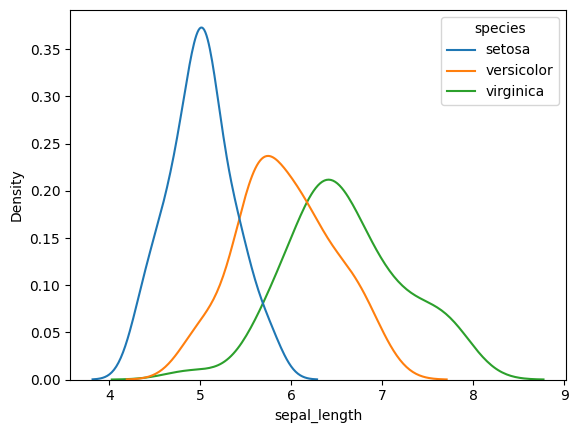

In [ ]:
sns.kdeplot(data=df,x='sepal_length',hue='species')

<Axes: xlabel='sepal_width', ylabel='Density'>

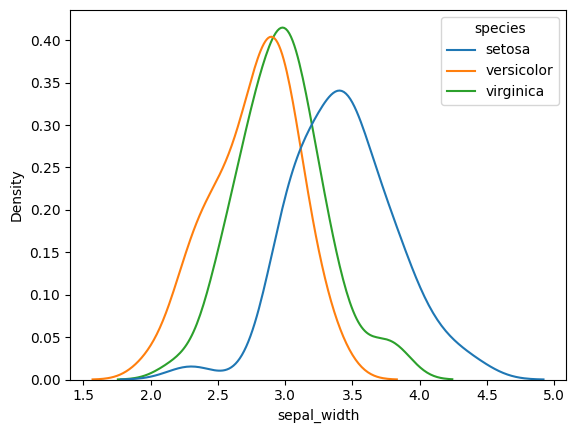

In [ ]:
sns.kdeplot(data=df,x='sepal_width',hue='species')

<Axes: xlabel='petal_length', ylabel='Density'>

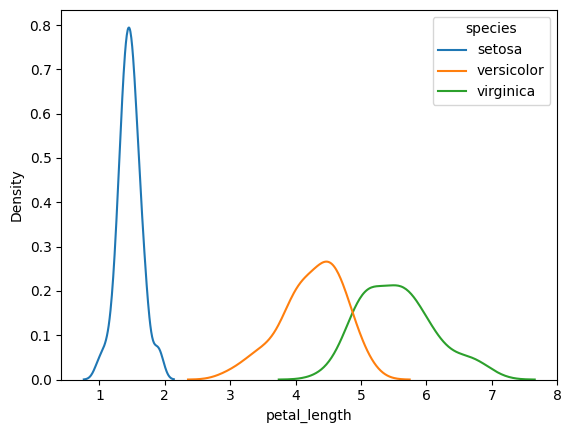

In [ ]:
sns.kdeplot(data=df,x='petal_length',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

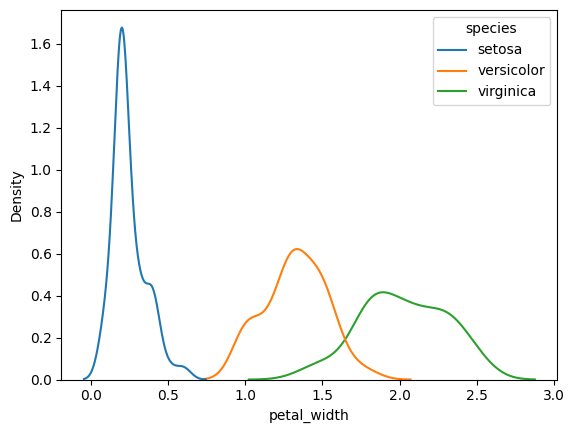

In [ ]:
sns.kdeplot(data=df,x='petal_width',hue='species')

<Axes: xlabel='petal_width', ylabel='Density'>

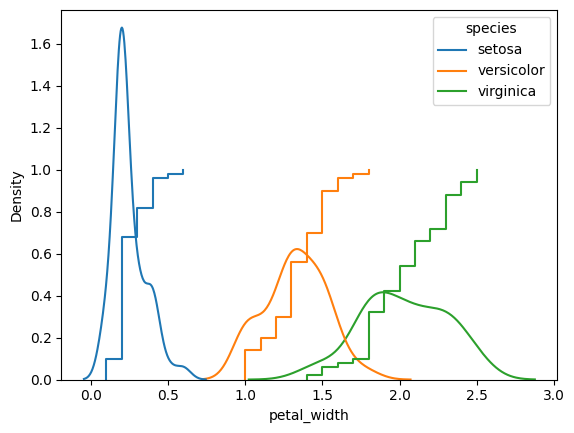

In [ ]:
sns.kdeplot(data=df, x='petal_width', hue='species')
sns.ecdfplot(data=df,x='petal_width',hue='species')

In [ ]:
import pandas as pd
titanic = pd.read_csv("/content/titanic.csv")

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

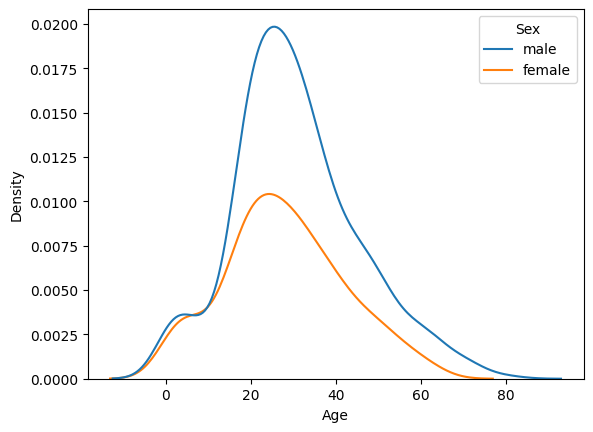

In [ ]:
# code here
sns.kdeplot(data=titanic,x='Age',hue='Sex')

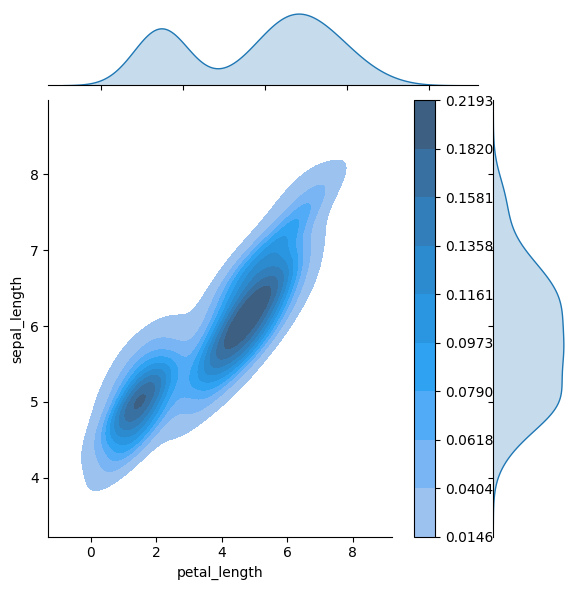

In [ ]:
 sns.jointplot(data=df, x="petal_length", y="sepal_length", kind="kde",fill=True,cbar=True)

<Axes: xlabel='Age', ylabel='Density'>

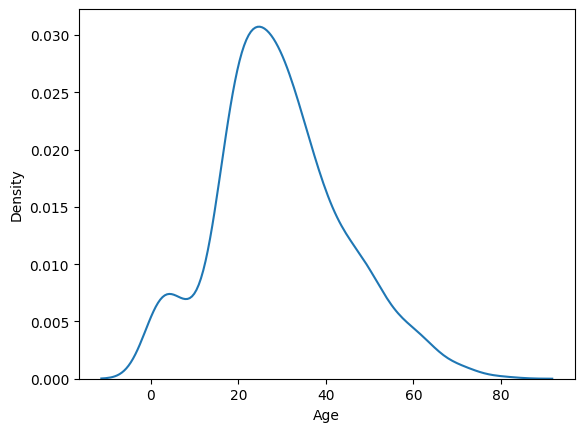

In [ ]:
sns.kdeplot(titanic['Age'])

In [ ]:
titanic['Age'].mean()

np.float64(29.69911764705882)

In [ ]:
x = (titanic['Age'] - titanic['Age'].mean())/titanic['Age'].std()

<Axes: xlabel='Age', ylabel='Density'>

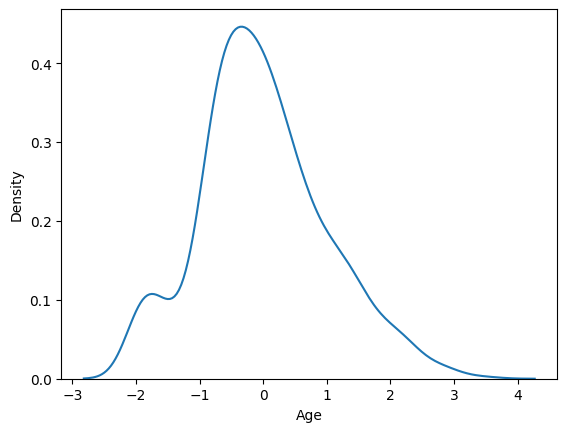

In [ ]:
sns.kdeplot(x)

In [ ]:
x.mean()

np.float64(2.388378943731429e-16)

In [ ]:
x.std()

0.9999999999999994

In [ ]:
titanic['Age'].skew()

np.float64(0.38910778230082704)

In [ ]:
titanic['Age'].mean() + 3*titanic['Age'].std()

np.float64(73.27860964406095)

In [ ]:
titanic['Age'].mean() - 3*titanic['Age'].std()

np.float64(-13.88037434994331)

In [ ]:
titanic[titanic['Age'] > 73]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [ ]:
titanic['Age'].max()

80.0